<a href="https://colab.research.google.com/github/jahern19/Stock-analysis/blob/main/ai_effect_on_volatility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of How Volatility in Technology Equities Shifts as a Result of the AI Regime

## Research Objective

This project aims to investigate the difference in behavior, volatility, correlation, and future price dynamics of major technology equities from before and after the AI regime using both quantitative and stochastic methods.

The analysis focuses on:
- NVIDIA (NVDA)
- Apple (AAPL)
- SPDR S&P 500 ETF (SPY)

Methods include:
- return analysis
- rolling volatility
- rolling correlation
- Monte Carlo simulation
- drawdown analysis

The goal is to better understand the effect of artificial intelligence on market behavior, risk, volatility, and uncertainrg in large technology equities.

In [5]:
!pip install yfinance --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [6]:
tickers = ["NVDA", "AAPL", "SPY"]

data = yf.download(
    tickers,
    start="2020-01-01",
    end="2025-01-01"
)['Close']

data.head()

/tmp/ipykernel_2351/734399428.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  3 of 3 completed


Ticker,AAPL,NVDA,SPY
Date,,,
2020-01-02,72.333878,5.970754,296.888184
2020-01-03,71.630646,5.875187,294.640045
2020-01-06,72.201408,5.899826,295.764160
2020-01-07,71.861847,5.971251,294.932587
2020-01-08,73.017845,5.982450,296.504425


## Dataset

Historical adjusted closing prices were collected using Yahoo Finance data through the yfinance Python library.

The selected assets represent:
- NVDA: AI and semiconductor exposure
- AAPL: consumer technology and hardware
- SPY: broad U.S. equity market benchmark


In [8]:
returns = data.pct_change().dropna()

returns.head()

Ticker,AAPL,NVDA,SPY
Date,,,
2020-01-03,-0.009722,-0.016006,-0.007572
2020-01-06,0.007968,0.004194,0.003815
2020-01-07,-0.004703,0.012106,-0.002812
2020-01-08,0.016086,0.001876,0.005329
2020-01-09,0.021241,0.010983,0.006781


Returns are used instead of prices because they approximate a stationary stochastic process, which is a key assumption in most statistical and financial models.

This transformation allows:
- comparison across assets with different price scales
- meaningful volatility estimation
- correlation analysis between time series

## Defining the AI Regime

This study defines the “AI regime” as the period beginning in late 2022, when large-scale adoption of generative AI technologies (ChatGPT, Claude, Grok, etc.) significantly influenced semiconductor demand and equity valuations.

We compare pre-AI (2020–2022) and post-AI (2023–present) market behavior.

In [24]:
pre_ai = returns.loc[:'2022-11-30']
post_ai = returns.loc['2022-12-01':]

In [25]:
returns.describe()

Ticker,AAPL,NVDA,SPY
count,1257.000000,1257.000000,1257.000000
mean,0.001182,0.003050,0.000618
std,0.019956,0.033940,0.013227
min,-0.128647,-0.184521,-0.109424
25%,-0.008425,-0.015996,-0.005150
50%,0.001187,0.003291,0.000900
75%,0.011989,0.022306,0.007292
max,0.119808,0.243696,0.090603


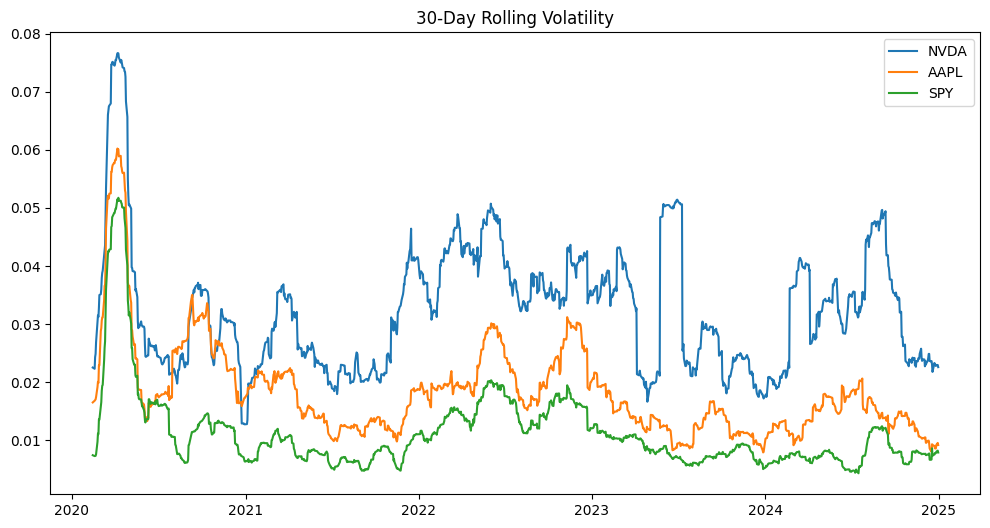

In [26]:
rolling_vol = returns.rolling(30).std()

plt.figure(figsize=(12,6))

for t in tickers:
    plt.plot(rolling_vol[t], label=t)

plt.title("30-Day Rolling Volatility")
plt.legend()
plt.show()

Volatility measures the dispersion of returns and is interpreted as a proxy for financial risk.

The results suggest that risk clusters in regimes rather than remain constant over time.

In particular, NVDA exhibits sharper and more frequent volatility spikes compared to AAPL and SPY, indicating a higher sensitivity to market events and a potential for regime-dependent behavior rather than stable stochastic variance.

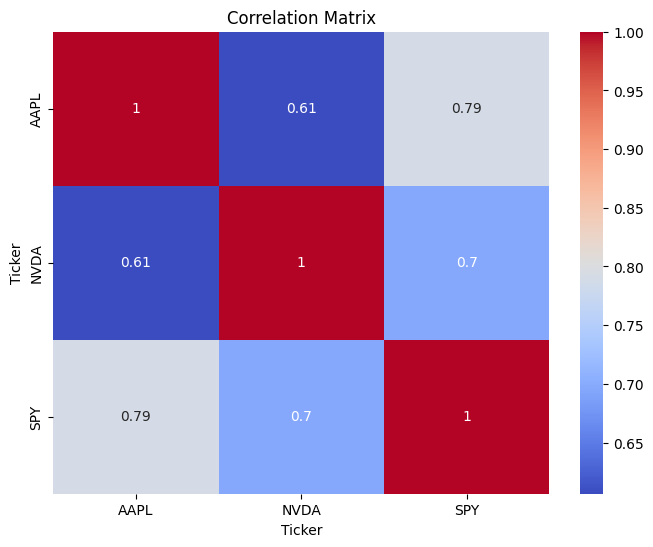

In [27]:
corr = returns.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

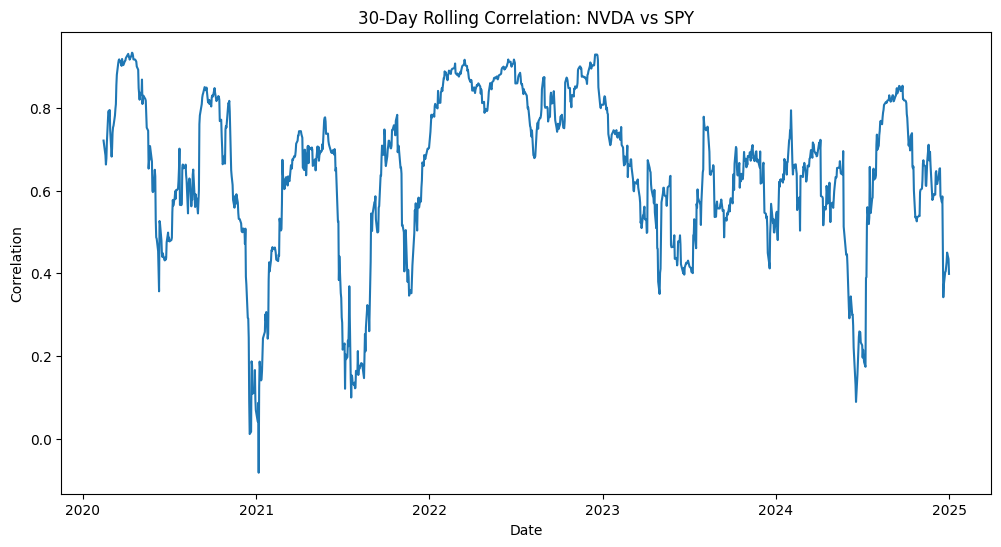

In [12]:
rolling_corr = returns['NVDA'].rolling(window=30).corr(returns['SPY'])

plt.figure(figsize=(12,6))

plt.plot(rolling_corr)

plt.title("30-Day Rolling Correlation: NVDA vs SPY")
plt.xlabel("Date")
plt.ylabel("Correlation")

plt.show()

In [28]:
vol_pre = pre_ai.std()
vol_post = post_ai.std()

vol_df = pd.DataFrame({
    "Pre-AI": vol_pre,
    "Post-AI": vol_post
})

vol_df

,Pre-AI,Post-AI
Ticker,,
AAPL,0.023374,0.013821
NVDA,0.035292,0.031927
SPY,0.015854,0.008244


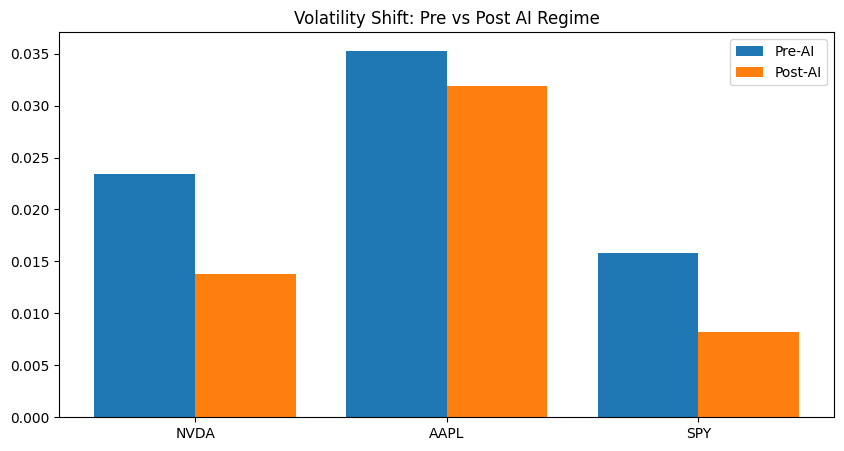

In [29]:
x = np.arange(len(tickers))

plt.figure(figsize=(10,5))

plt.bar(x - 0.2, vol_pre, width=0.4, label="Pre-AI")
plt.bar(x + 0.2, vol_post, width=0.4, label="Post-AI")

plt.xticks(x, tickers)
plt.title("Volatility Shift: Pre vs Post AI Regime")
plt.legend()
plt.show()

In [33]:
from scipy import stats

for t in tickers:
    pre_data = pre_ai[t].dropna()
    post_data = post_ai[t].dropna()

    stat, pval = stats.levene(pre_data, post_data)

    print(f"{t}")
    print("p-value:", pval)
    print()

NVDA
p-value: 0.013463385674040077

AAPL
p-value: 8.909865066767946e-16

SPY
p-value: 3.7781538432836006e-14



To formally test whether volatility differs between regimes, a Levene test is used.

This test evaluates the null hypothesis that the variance of returns is equal across pre-AI and post-AI periods.

A statistically significant result (p < 0.05) suggests evidence of a structural change in volatility behavior, consistent with a regime shift in the underlying process.

The test has shown that all three equities display a p value less than .05, with NVDA surprisingly having a significantly larger p than APPL and SPY. This may suggest that NVDA was already a volatile equity before the AI regime, and was less affected in volatility by the shift towards AI. On the other hand, APPL and SPY experienced significant change.

In [36]:
ticker = "NVDA"

prices = data[ticker].dropna()
mu = returns[ticker].mean()
sigma = returns[ticker].std()

S0 = prices.iloc[-1]
T = 252
simulations = 1000
dt = 1 / T

paths = np.zeros((T, simulations))

for i in range(simulations):
    sim = [S0]

    for t in range(T):
        Z = np.random.normal()
        next_price = sim[-1] * np.exp(
            (mu - 0.5*sigma**2)*dt + sigma*np.sqrt(dt)*Z
        )
        sim.append(next_price)

    paths[:, i] = sim[1:]

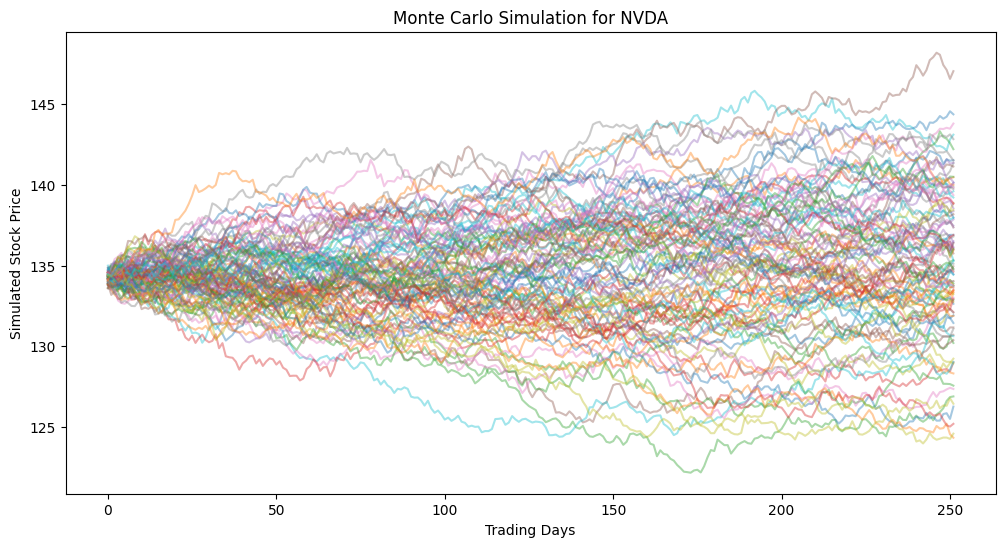

In [16]:
plt.figure(figsize=(12,6))

plt.plot(price_paths[:, :100], alpha=0.4)

plt.title("Monte Carlo Simulation for NVDA")
plt.xlabel("Trading Days")
plt.ylabel("Simulated Stock Price")

plt.show()

Monte Carlo simulation models future price evolution as a stochastic process under assumptions of constant drift and volatility.

Each simulated path represents a possible realization of a geometric Brownian motion process.

This produces a probability distribution of outcomes rather than a single predicted value, highlighting the inherent uncertainty in financial systems.

However, this model assumes stationarity and normally distributed returns, both of which may be violated in real markets.

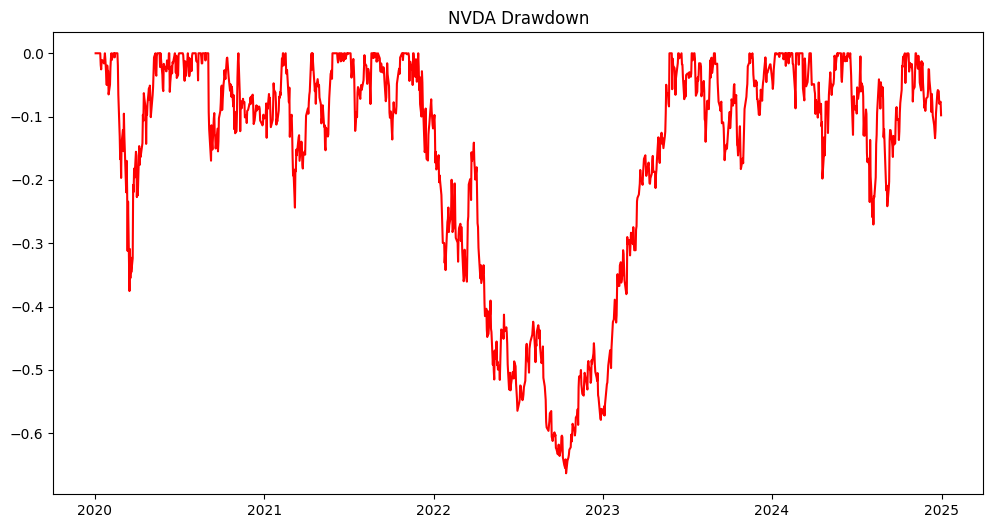

In [34]:
cum = (1 + returns["NVDA"]).cumprod()
peak = cum.cummax()
drawdown = (cum - peak) / peak

plt.figure(figsize=(12,6))
plt.plot(drawdown, color="red")
plt.title("NVDA Drawdown")
plt.show()

## Limitations

- Markets are non-stationary
- Volatility is time-varying
- Monte Carlo assumes constant drift and variance
- AI regime definition is approximate, not causal

## Conclusion

The analysis suggests that post-2022 AI adoption corresponds with, but provides no assumption of causation to, measurable changes in volatility and risk structure across major technology equities.

Statistical testing indicates that volatility differences between pre- and post-AI regimes are significant for multiple assets, particularly SPY and AAPL, while NVDA remained highly volatile throughout both time periods.

This supports the hypothesis that a market shift towards AI is associated with structural changes in equity behavior rather than purely short-term fluctuations.